# 1. Importing the necessary Libraries

In [1]:
## Importing the necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)

## Importing Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Importing Evaluation Functions
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score, roc_curve, auc, roc_auc_score

# 2. Load the dataset

In [2]:
data = pd.read_csv('../data\Telco_Customer_Churn.csv')

# 3. Data Cleaning

In [3]:
data.shape

(7043, 21)

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
## Changing 'TotalCharges' Datatype to numeric
## errors='coerce' verify invalid number should be converted into nan value
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')


In [7]:
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
## Droping the 'TotalCharges' nan value rows
original_rows = len(data)
data.dropna(subset=['TotalCharges'], inplace=True)
print(f"Total dropped row with NaNs: {original_rows-len(data)}")

Total dropped row with NaNs: 11


In [9]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [11]:
X = data[numeric_features + categorical_features]
y = data[target_feature]

In [12]:
## Checking the Distribution of target feature
from collections import Counter
Counter(y)

Counter({'No': 5163, 'Yes': 1869})

* The data is imbalanced since yes or no are not 50-50

# 4. Train Test Split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
#In train_test_split, the stratify parameter ensures that the proportions of class labels in the training and testing sets are approximately the same as the proportions in the original dataset.

In [14]:
y_train = y_train.map({'Yes': 1, 'No':0})
y_test = y_test.map({'Yes': 1, 'No':0})
y = y.map({'Yes': 1, 'No':0})

In [15]:
## Check Balance of the Dataset
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Original data churn rate: 0.27
Training data churn rate: 0.27
Testing data churn rate: 0.27


# 5. Data Preprocessing

In [16]:
from sklearn.compose import ColumnTransformer

## Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[ 
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])

## Categorical Preprocessing Batch 

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## Combine Both Batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop'
)


# 6. Model Training

## (I) Logistic Regression

### Model

In [17]:
## Create the final full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42
    ))
])

## class_weight='balanced' It make sure the model will be not biased towards not to churn through giving the more priorit to the minority('Yes')

In [18]:
## Train the model
clf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
## Predict the model
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[0 1 0 ... 0 1 1]


In [20]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)

[0.28384175 0.7014269  0.39707558 ... 0.12920782 0.66243249 0.60988537]


In [21]:
print(recall_score(y_test, y_predict))

0.7967914438502673


In [22]:
print(confusion_matrix(y_test, y_predict))

[[1130  419]
 [ 114  447]]


In [23]:
print(precision_score(y_test, y_predict))

0.5161662817551963


In [24]:
print(accuracy_score(y_test, y_predict))

0.74739336492891


In [25]:
print(f1_score(y_test, y_predict))

0.626489138051857


In [26]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1549
           1       0.52      0.80      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.75      0.76      2110



In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8376734343012397


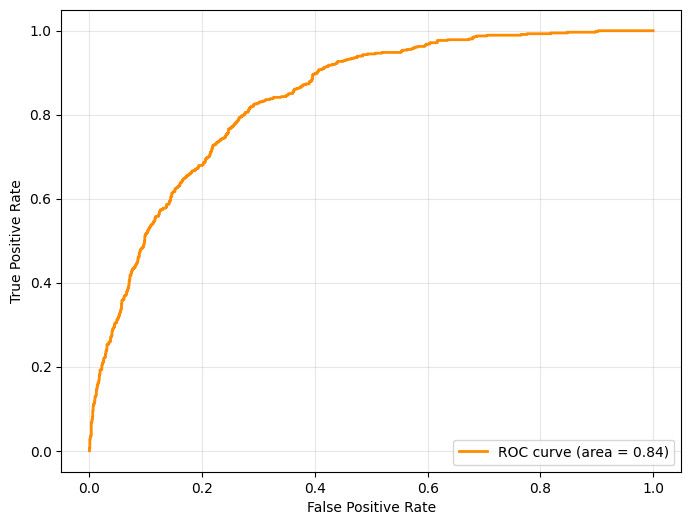

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Cross Validation

In [29]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.8477149116775218


## (II) RandomForest Classifier

### Model

In [30]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

In [31]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [33]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.45      0.52       561

    accuracy                           0.78      2110
   macro avg       0.72      0.67      0.69      2110
weighted avg       0.77      0.78      0.77      2110



In [34]:
print(confusion_matrix(y_test, y_pred_rf))

[[1393  156]
 [ 309  252]]


In [35]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.8113071626913574


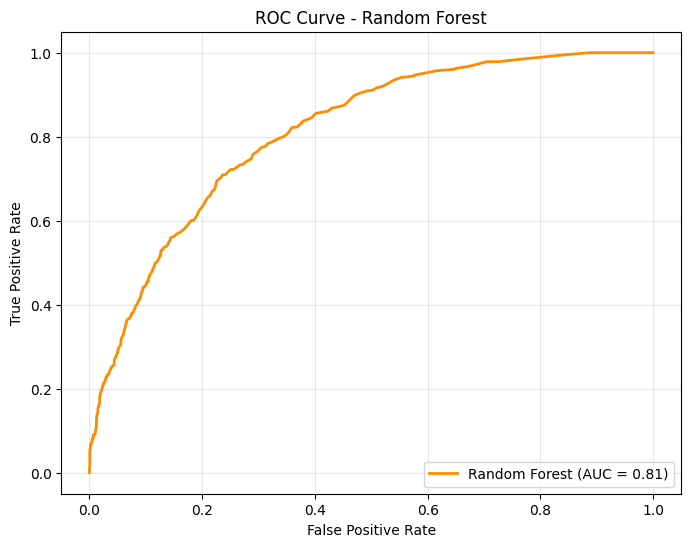

In [36]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Cross Validation

In [37]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8229816516998145


### Hyperparameter Tunning

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [39]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [40]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC: 0.845051536182828


In [41]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.8410831437452028
0.762085308056872
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1549
           1       0.54      0.74      0.62       561

    accuracy                           0.76      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.80      0.76      0.77      2110



### Information of preprocessed Important features 

In [42]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
37,cat__Contract_Month-to-month,0.131776
2,num__tenure,0.130282
1,num__TotalCharges,0.099267
0,num__MonthlyCharges,0.070290
19,cat__OnlineSecurity_No,0.060712
39,cat__Contract_Two year,0.055245
17,cat__InternetService_Fiber optic,0.047280
28,cat__TechSupport_No,0.046763
44,cat__PaymentMethod_Electronic check,0.029720
16,cat__InternetService_DSL,0.020819


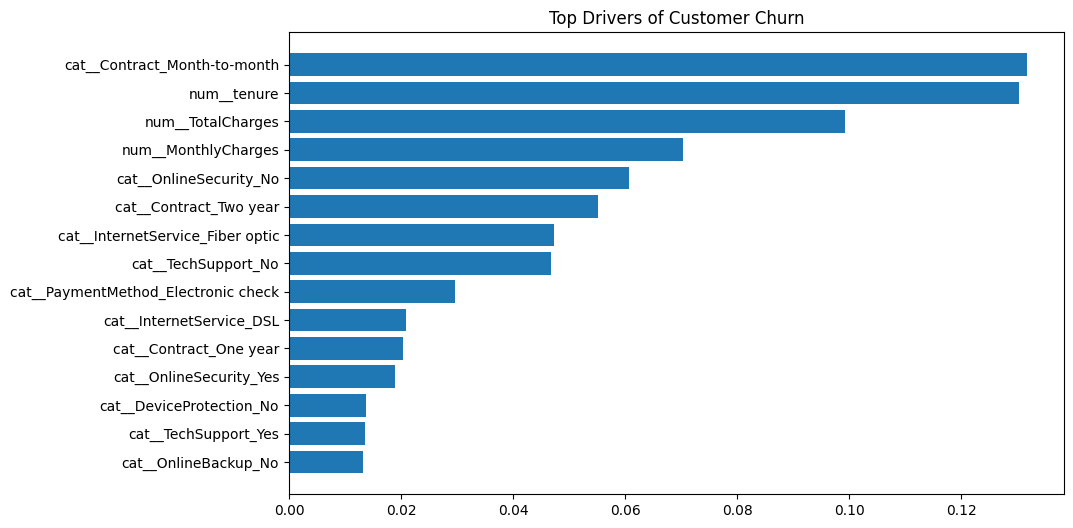

In [43]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [44]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.10,0.341008,0.976827,0.505535
1,0.15,0.369314,0.969697,0.534907
2,0.20,0.396873,0.950089,0.559874
3,0.25,0.419723,0.918004,0.576063
4,0.30,0.446524,0.893048,0.595365
5,0.35,0.478389,0.868093,0.616846
6,0.40,0.500535,0.834225,0.625668
7,0.45,0.524648,0.796791,0.632696
8,0.50,0.538362,0.737968,0.622556
9,0.55,0.557971,0.686275,0.615508


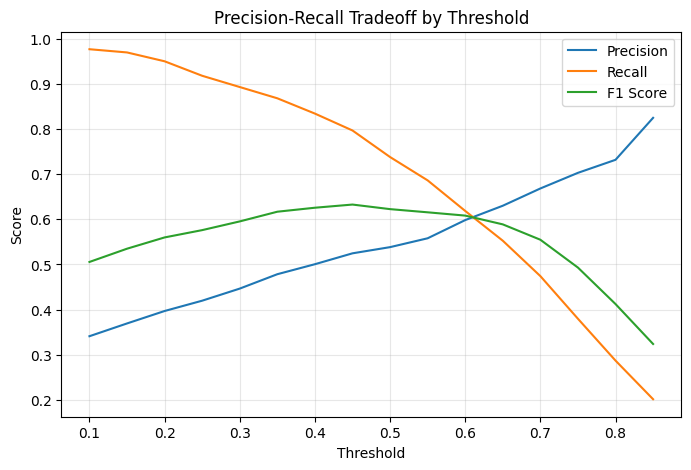

In [45]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()

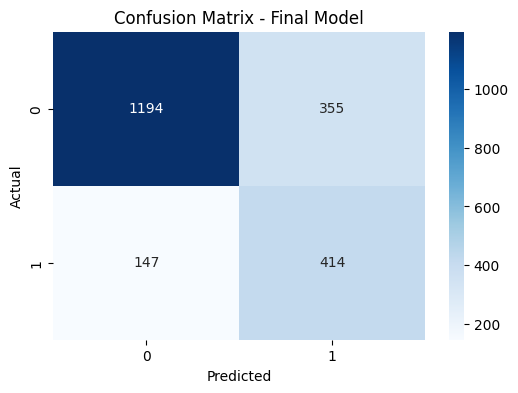

In [46]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

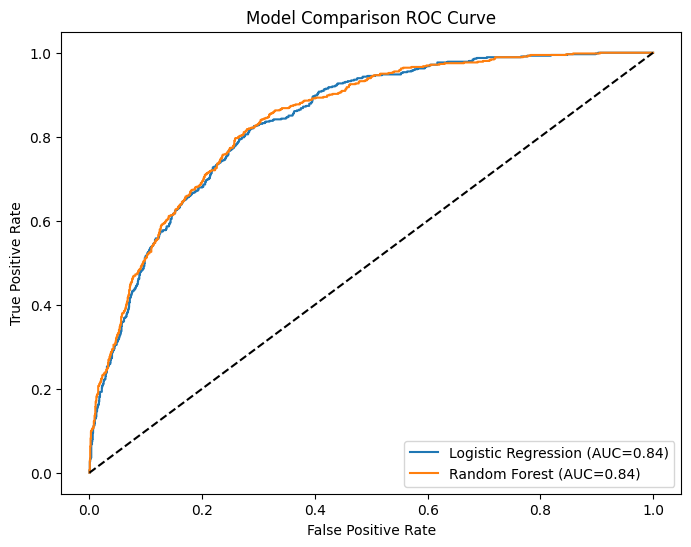

In [47]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [48]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df["risk_level"].value_counts()

risk_level
Low Risk       988
High Risk      580
Medium Risk    542
Name: count, dtype: int64

In [49]:
import sklearn
print(sklearn.__version__)

1.7.2


In [50]:
import shap
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

p:\anaconda3\envs\churn-predictor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [52]:
rf_classifier = best_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)

In [53]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
4922
(46, 2)
(4922, 46)


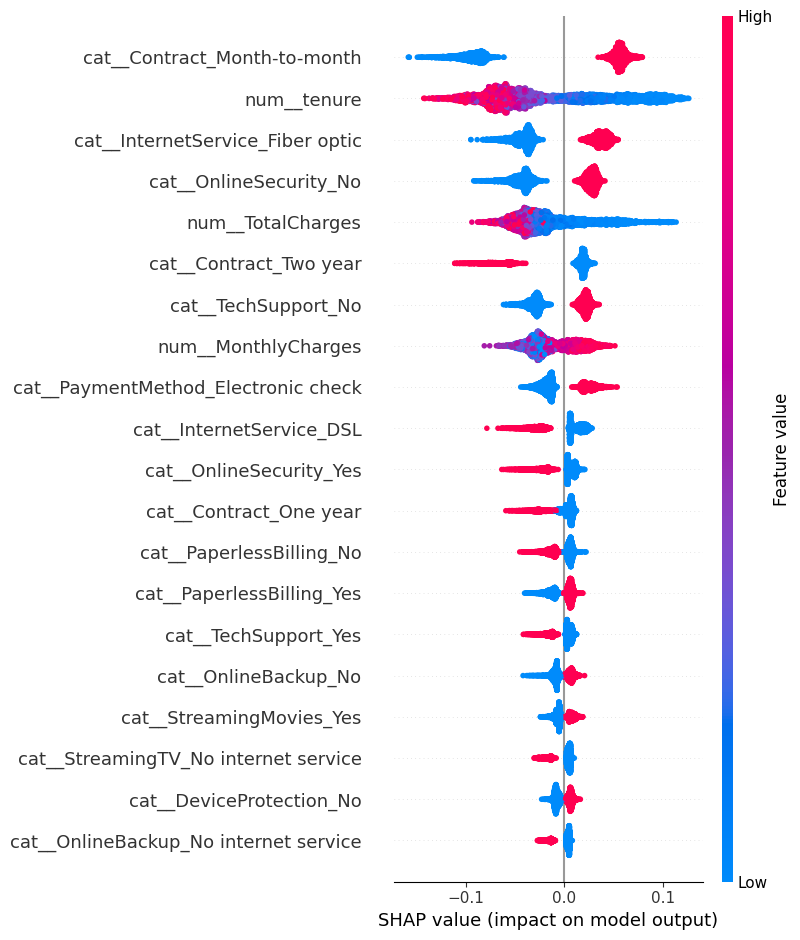

In [54]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names
)

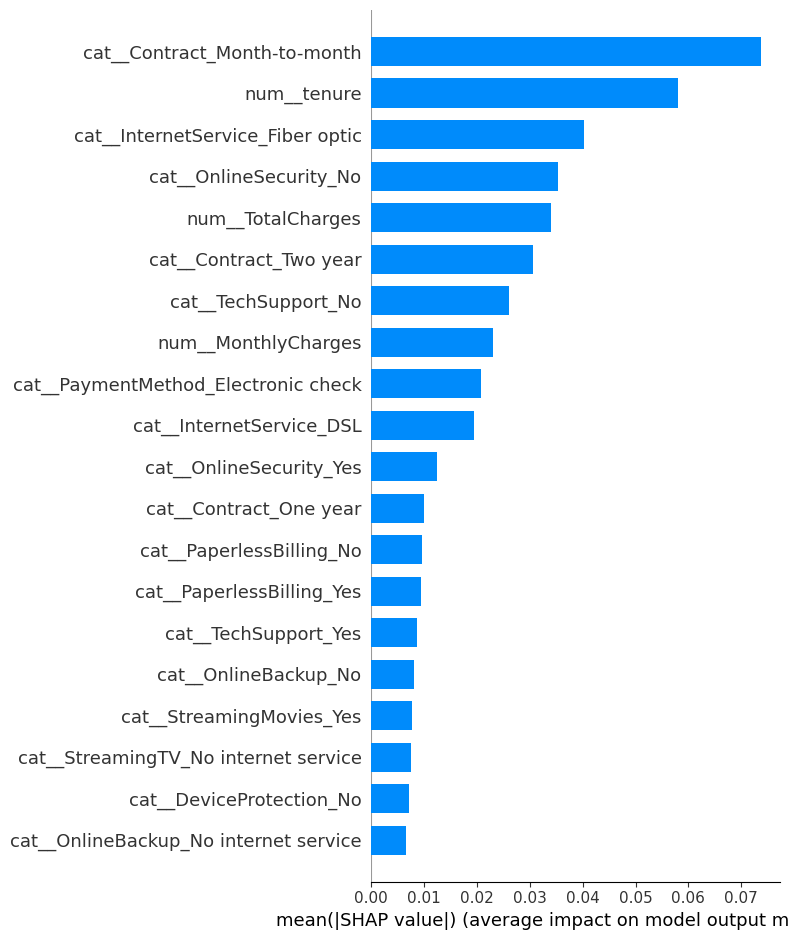

In [55]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

## (III)XGBoost Classifier

In [56]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [57]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [58]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1549
           1       0.52      0.79      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.75      0.76      2110

ROC AUC: 0.8427672847412337


# 7. Overall all the model Performance

In [60]:
performance_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC AUC": [0.86, 0.85, round(roc_auc_score(y_test, y_proba_xgb), 2)],
    "F1 Score": [0.64, 0.65, round(f1_score(y_test, y_pred_xgb), 2)],
    "Precision": [0.52, 0.56, round(precision_score(y_test, y_pred_xgb), 2)],
    "Recall": [0.84, 0.78, round(recall_score(y_test, y_pred_xgb), 2)]
})
performance_df

,Model,ROC AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.86,0.64,0.52,0.84
1,Random Forest,0.85,0.65,0.56,0.78
2,XGBoost,0.84,0.63,0.52,0.79


# 8. Saving all the models

In [61]:
import joblib

joblib.dump(clf_pipeline, "../artifacts/logistic_model.pkl")
joblib.dump(best_rf, "../artifacts/rf_model.pkl")
joblib.dump(xgb_model, "../artifacts/xgb_model.pkl")

['../artifacts/xgb_model.pkl']